#### 1. Цель EDA

В этом EDA используется EdTech-датасет OULAD (анонимизированный набор данных Open University Learning Analytics Dataset), содержащий данные о модулях, презентациях, оценочных мероприятиях, учебных материалах, регистрации студентов, результатах оценивания и активности в VLE (Virtual Learning Environment).

Подробное описание датасета и всех таблиц вынесено в отдельный файл: [описание датасета](../dataset_description.md)

ERD-диаграмма представлена [здесь](../pics/ERD_oulad.png)

Основная цель EDA — понять структуру EdTech-датасета, проверить качество данных, определить роль каждой таблицы в будущей аналитической модели и подготовить основу для дальнейшего SQL-анализа и визуализации.

#### 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
studinfo = pd.read_csv('../raw_data/studentInfo.csv')
studreg = pd.read_csv('../raw_data/studentRegistration.csv')
studvle = pd.read_csv('../raw_data/studentVle.csv')
courses = pd.read_csv('../raw_data/courses.csv')
studass = pd.read_csv('../raw_data/studentAssessment.csv')
assess = pd.read_csv('../raw_data/assessments.csv')
vle = pd.read_csv('../raw_data/vle.csv')


In [3]:
print(f'studentInfo: {studinfo.shape}')
print(f'studentRgistration: {studreg.shape}')
print(f'studentVle: {studvle.shape}')
print(f'courses: {courses.shape}')
print(f'studentAssessment: {studass.shape}')
print(f'assessments: {assess.shape}')
print(f'vle: {vle.shape}')

studentInfo: (32593, 12)
studentRgistration: (32593, 5)
studentVle: (10655280, 6)
courses: (22, 3)
studentAssessment: (173912, 5)
assessments: (206, 6)
vle: (6364, 6)


## studentInfo

In [4]:
studinfo.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 3.0 MB


In [5]:
studinfo.sample(10)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
25884,FFF,2013J,608453,M,South West Region,A Level or Equivalent,60-70%,35-55,0,120,N,Withdrawn
12436,CCC,2014J,657352,M,London Region,A Level or Equivalent,90-100%,0-35,0,150,N,Pass
9590,CCC,2014B,584446,F,Ireland,HE Qualification,NaN,0-35,0,120,N,Pass
25289,FFF,2013J,588236,M,South East Region,A Level or Equivalent,10-20,0-35,0,90,N,Pass
4235,BBB,2013J,601885,F,West Midlands Region,A Level or Equivalent,0-10%,0-35,0,60,N,Pass
29198,FFF,2014J,674935,M,Wales,A Level or Equivalent,90-100%,0-35,0,90,N,Withdrawn
27884,FFF,2014J,333993,M,North Western Region,A Level or Equivalent,20-30%,0-35,0,60,N,Pass
24535,FFF,2013J,523599,M,Wales,A Level or Equivalent,10-20,35-55,1,120,N,Pass
251,AAA,2013J,1640609,M,West Midlands Region,A Level or Equivalent,30-40%,35-55,0,60,N,Pass
26644,FFF,2014B,558244,M,Wales,HE Qualification,40-50%,35-55,2,120,N,Fail


In [6]:
studinfo.nunique()

code_module                 7
code_presentation           4
id_student              28785
gender                      2
region                     13
highest_education           5
imd_band                   10
age_band                    3
num_of_prev_attempts        7
studied_credits            61
disability                  2
final_result                4
dtype: int64

In [7]:
studinfo.duplicated(subset=['code_module', 'code_presentation', 'id_student']).sum()

np.int64(0)

In [8]:
studinfo['gender'].value_counts(dropna=False)

gender
M    17875
F    14718
Name: count, dtype: int64

In [9]:
studinfo['gender'].value_counts(normalize=True, dropna=False)

gender
M    0.548431
F    0.451569
Name: proportion, dtype: float64

In [10]:
studinfo['region'].value_counts(dropna=False)

region
Scotland                3446
East Anglian Region     3340
London Region           3216
South Region            3092
North Western Region    2906
West Midlands Region    2582
South West Region       2436
East Midlands Region    2365
South East Region       2111
Wales                   2086
Yorkshire Region        2006
North Region            1823
Ireland                 1184
Name: count, dtype: int64

In [11]:
studinfo['region'].value_counts(normalize=True, dropna=False)

region
Scotland                0.105728
East Anglian Region     0.102476
London Region           0.098671
South Region            0.094867
North Western Region    0.089160
West Midlands Region    0.079219
South West Region       0.074740
East Midlands Region    0.072562
South East Region       0.064769
Wales                   0.064001
Yorkshire Region        0.061547
North Region            0.055932
Ireland                 0.036327
Name: proportion, dtype: float64

In [12]:
studinfo['highest_education'].value_counts(dropna=False)

highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64

In [13]:
studinfo['highest_education'].value_counts(normalize=True, dropna=False)

highest_education
A Level or Equivalent          0.430921
Lower Than A Level             0.403706
HE Qualification               0.145123
No Formal quals                0.010646
Post Graduate Qualification    0.009603
Name: proportion, dtype: float64

|Уровень образования|Интерпретация|
|---|---|
|No Formal quals|Отсутствие формального образования|
|Lower Than A Level|Средняя школа|
|A Level or Equivalent|Старшая школа|
|HE Qualification|Бакалавриат / специалитет|
|Post Graduate Qualification|Магиструтура и выше|

In [14]:
studinfo['imd_band'].value_counts(dropna=False)

imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
NaN        1111
Name: count, dtype: int64

In [15]:
studinfo['imd_band_clean'] = studinfo['imd_band'].replace({'10-20': '10-20%'})

In [16]:
studinfo['imd_band_clean'].value_counts(dropna=False)

imd_band_clean
20-30%     3654
30-40%     3539
10-20%     3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
NaN        1111
Name: count, dtype: int64

В столбце `imd_band` выявлено значение 10-20, тогда как остальные интервалы заданы в процентном формате. По структуре признака и общей логике шкалы значение было интерпретировано как 10-20% и приведено к единому формату в отдельном очищенном поле `imd_band_clean`.

In [17]:
studinfo['imd_band_clean'].value_counts(normalize=True, dropna=False)

imd_band_clean
20-30%     0.112110
30-40%     0.108582
10-20%     0.107876
0-10%      0.101586
40-50%     0.099899
50-60%     0.095849
60-70%     0.089130
70-80%     0.088332
80-90%     0.084742
90-100%    0.077808
NaN        0.034087
Name: proportion, dtype: float64

In [18]:
studinfo['imd_band_missing'] = studinfo['imd_band'].isna()

In [19]:
region_missing = (
    pd.crosstab(studinfo['region'], studinfo['imd_band_missing'], normalize='index') * 100
).rename(columns={False: 'not_missing_pct', True: 'missing_pct'}).sort_values('missing_pct', ascending=False)

region_missing

imd_band_missing,not_missing_pct,missing_pct
region,,
North Region,59.901262,40.098738
Ireland,77.533784,22.466216
South Region,98.447607,1.552393
West Midlands Region,98.489543,1.510457
Scotland,99.651770,0.348230
Yorkshire Region,99.750748,0.249252
South West Region,99.794745,0.205255
North Western Region,99.827942,0.172058
East Anglian Region,100.000000,0.000000


<Axes: ylabel='region'>

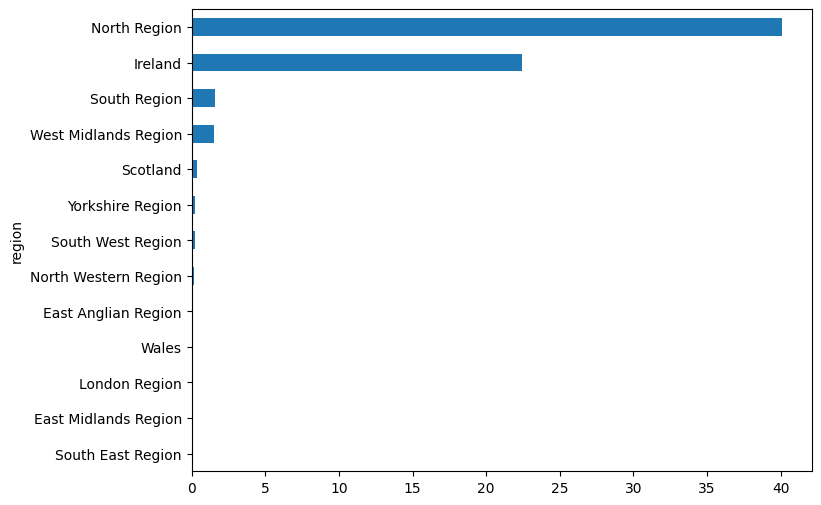

In [20]:
region_missing.sort_values('missing_pct', ascending=True)['missing_pct'].plot(kind='barh', figsize=(8,6))

Пропуски в `imd_band` распределены неравномерно по регионам. Наибольшая доля пропусков наблюдается в North Region (40.1%) и Ireland (22.5%), тогда как в ряде регионов пропуски отсутствуют полностью. Это указывает на систематический характер пропусков и позволяет предположить, что отсутствие `imd_band` связано с региональными особенностями формирования или сопоставления данных, а не со случайной потерей значений.

In [21]:
studinfo['age_band'].value_counts(dropna=False)

age_band
0-35     22944
35-55     9433
55<=       216
Name: count, dtype: int64

In [22]:
studinfo['age_band'].value_counts(normalize=True, dropna=False)

age_band
0-35     0.703955
35-55    0.289418
55<=     0.006627
Name: proportion, dtype: float64

In [23]:
studinfo['age_band_clean'] = studinfo['age_band'].replace({
    '55<=': '55+'
})

В столбце `age_band` возраст представлен не точными значениями, а категориальными диапазонами. Метка 55<= выглядит как некорректная запись и по контексту интерпретируется как 55+ (>=55). Поскольку официальное описание датасета не уточняет правила включения граничных значений, признак далее рассматривается как упорядоченная категориальная переменная, а не как точный числовой интервал.

Поле `age_band` приведено к единому формату в отдельном очищенном поле `age_band_clean`.

In [24]:
studinfo.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'imd_band_clean',
       'imd_band_missing', 'age_band_clean'],
      dtype='str')

In [25]:
studinfo = studinfo[['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'imd_band_clean', 'age_band', 'age_band_clean',
       'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'imd_band_missing']]

In [26]:
studinfo['num_of_prev_attempts'].value_counts(dropna=False)

num_of_prev_attempts
0    28421
1     3299
2      675
3      142
4       39
5       13
6        4
Name: count, dtype: int64

In [27]:
studinfo['num_of_prev_attempts'].value_counts(normalize=True, dropna=False)

num_of_prev_attempts
0    0.871997
1    0.101218
2    0.020710
3    0.004357
4    0.001197
5    0.000399
6    0.000123
Name: proportion, dtype: float64

In [28]:
studinfo['studied_credits'].describe()

count    32593.000000
mean        79.758691
std         41.071900
min         30.000000
25%         60.000000
50%         60.000000
75%        120.000000
max        655.000000
Name: studied_credits, dtype: float64

In [46]:
studinfo.groupby('studied_credits').studied_credits.size().sort_values(ascending=False)

studied_credits
60     16751
120     6328
30      3749
90      3144
180      830
       ...  
480        1
540        1
585        1
630        1
655        1
Name: studied_credits, Length: 61, dtype: int64

<Axes: ylabel='Frequency'>

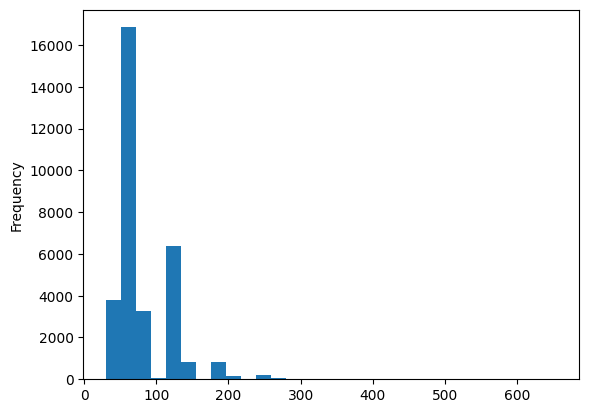

In [54]:
studinfo['studied_credits'].plot(kind='hist', bins=30)

In [53]:
studinfo['studied_credits_band'] = pd.cut(
    studinfo['studied_credits'],
    bins=[0, 30, 60, 120, 240, float('inf')],
    labels=['<=30', '31-60', '61-120', '121-240', '241+'],
    right=True
)
studinfo.groupby('studied_credits_band').size()

studied_credits_band
<=30        3749
31-60      16819
61-120      9769
121-240     2140
241+         116
dtype: int64

Признак `studied_credits` отражает учебную нагрузку студента. Распределение правосторонне скошено: основная часть наблюдений сосредоточена на низких и средних значениях, при этом видны выраженные пики на типовых уровнях нагрузки, прежде всего около 60 и 120 кредитов. 

Показатель интерпретируется как proxy общей учебной нагрузки из институционального хранилища, а не как точное число модулей в анализируемом срезе данных.

Читать `studied_credits` так:
* 30 — низкая нагрузка;
* 60 — нормальная part-time (16–18 часов учёбы в неделю);
* 90 — повышенная;
* 120 — full-time эквивалент (32–36 часа учёбы в неделю);
* 240+ — уже нетипично для стандартной OU-траектории и требует отдельной проверки, потому что это может быть редкий профиль студента, особая комбинация модулей или артефакт данных/исторической записи. 

OU официально указывает максимум 120 credits в год как full-time эквивалент.

In [29]:
studinfo['disability'].value_counts(dropna=False)

disability
N    29429
Y     3164
Name: count, dtype: int64

In [30]:
studinfo['disability'].value_counts(normalize=True, dropna=False)

disability
N    0.902924
Y    0.097076
Name: proportion, dtype: float64

In [31]:
studinfo['final_result'].value_counts(dropna=False)

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [32]:
studinfo['final_result'].value_counts(normalize=True, dropna=False)

final_result
Pass           0.379253
Withdrawn      0.311601
Fail           0.216365
Distinction    0.092781
Name: proportion, dtype: float64

## studentRegistration

In [33]:
studreg.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  str    
 1   code_presentation    32593 non-null  str    
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1.2 MB


In [34]:
studreg.sample(10)

,code_module,code_presentation,id_student,date_registration,date_unregistration
22255,EEE,2014J,2290886,-10.0,NaN
4281,BBB,2013J,603601,-32.0,NaN
32186,GGG,2014J,649194,-106.0,NaN
13464,DDD,2013B,433386,-52.0,NaN
30138,GGG,2013J,393451,-89.0,NaN
2047,BBB,2013B,551954,-25.0,NaN
3725,BBB,2013J,581959,-87.0,-24.0
25286,FFF,2013J,588131,-59.0,NaN
26242,FFF,2014B,130992,-121.0,NaN
23917,FFF,2013J,39882,-32.0,-31.0


In [76]:
studreg.nunique()

code_module                7
code_presentation          4
id_student             28785
date_registration        332
date_unregistration      416
dtype: int64

In [77]:
studreg.duplicated(subset=['code_module', 'code_presentation', 'id_student']).sum()

np.int64(0)

In [ ]:
# кол-во регистраций на студента
studreg.groupby('id_student').size().value_counts().sort_index().rename_axis('registrations_per_student').reset_index(name='student_count')

,registrations_per_student,student_count
0,1,25247
1,2,3293
2,3,221
3,4,23
4,5,1


In [ ]:
# когорты
studreg.groupby(['code_module', 'code_presentation']).size().sort_values(ascending=False)

code_module  code_presentation
CCC          2014J                2498
FFF          2014J                2365
BBB          2014J                2292
FFF          2013J                2283
BBB          2013J                2237
DDD          2013J                1938
CCC          2014B                1936
DDD          2014J                1803
BBB          2013B                1767
FFF          2013B                1614
BBB          2014B                1613
FFF          2014B                1500
DDD          2013B                1303
             2014B                1228
EEE          2014J                1188
             2013J                1052
GGG          2013J                 952
             2014B                 833
             2014J                 749
EEE          2014B                 694
AAA          2013J                 383
             2014J                 365
dtype: int64

In [79]:
studreg[['date_registration', 'date_unregistration']].describe()

,date_registration,date_unregistration
count,32548.000000,10072.000000
mean,-69.411300,49.757645
std,49.260522,82.460890
min,-322.000000,-365.000000
25%,-100.000000,-2.000000
50%,-57.000000,27.000000
75%,-29.000000,109.000000
max,167.000000,444.000000


<Axes: ylabel='Frequency'>

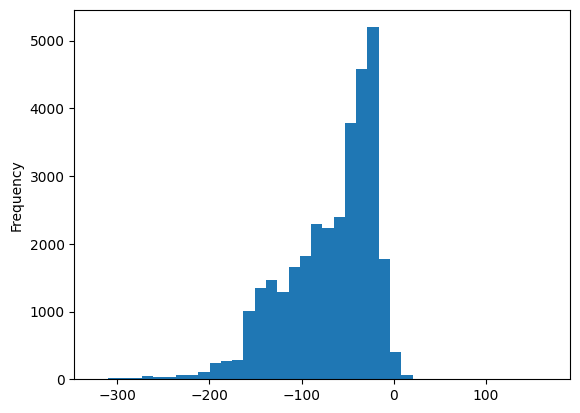

In [93]:
studreg['date_registration'].plot(kind='hist', bins=40)

In [103]:
studreg['registration_band'] = pd.cut(
    studreg['date_registration'],
    bins=[-400, -180, -90, -30, -1, 30, 90, 180],
    labels=[
        'before_180plus',
        'before_180_90',
        'before_90_30',
        'before_30_1',
        'after_0_30',
        'after_31_90',
        'after_91_180'
    ],
    include_lowest=True
)

studreg['registration_band'].value_counts(dropna=False)

registration_band
before_90_30      14308
before_180_90      8996
before_30_1        8205
before_180plus      803
after_0_30          220
NaN                  45
after_31_90          12
after_91_180          4
Name: count, dtype: int64

In [108]:
studreg['registration_band'].value_counts(normalize=True, dropna=False)

registration_band
before_90_30      0.438990
before_180_90     0.276010
before_30_1       0.251741
before_180plus    0.024637
after_0_30        0.006750
NaN               0.001381
after_31_90       0.000368
after_91_180      0.000123
Name: proportion, dtype: float64

In [104]:
studreg['unregistration_band'] = pd.cut(
    studreg['date_unregistration'],
    bins=[-400, -1, 30, 90, 180, 500],
    labels=[
        'before_0',
        'after_0_30',
        'after_31_90',
        'after_91_180',
        'after_181plus'
    ],
    include_lowest=True
)

studreg['unregistration_band'].value_counts(dropna=False)

unregistration_band
NaN              22521
before_0          2678
after_0_30        2449
after_91_180      2287
after_31_90       1904
after_181plus      754
Name: count, dtype: int64

In [109]:
studreg['unregistration_band'].value_counts(normalize=True, dropna=False)

unregistration_band
NaN              0.690977
before_0         0.082165
after_0_30       0.075139
after_91_180     0.070168
after_31_90      0.058417
after_181plus    0.023134
Name: proportion, dtype: float64

In [85]:
studreg[['date_registration']].isna().sum()

date_registration    45
dtype: int64

In [110]:
studreg[studreg['date_registration'].isna()].head()

,code_module,code_presentation,id_student,date_registration,date_unregistration,registration_band,unregistration_band
2344,BBB,2013B,630346,NaN,NaN,NaN,NaN
2538,BBB,2013J,57369,NaN,-1.0,NaN,before_0
2759,BBB,2013J,342678,NaN,-33.0,NaN,before_0
5356,BBB,2014B,582496,NaN,-126.0,NaN,before_0
5490,BBB,2014B,607646,NaN,-38.0,NaN,before_0


В таблице `studreg` обнаружено 45 записей с пропущенным `date_registration` (≈0.14% от всех строк). Наличие строк в таблице указывает на факт регистрации студента на module + presentation, однако точная дата регистрации для этих наблюдений отсутствует. В части записей при этом указана date_unregistration, что говорит о снятии с курса при отсутствии информации о дате первоначальной регистрации. Такие случаи следует трактовать как пропуски в данных.

## studentVle

In [35]:
studvle.info()

<class 'pandas.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype
---  ------             -----
 0   code_module        str  
 1   code_presentation  str  
 2   id_student         int64
 3   id_site            int64
 4   date               int64
 5   sum_click          int64
dtypes: int64(4), str(2)
memory usage: 487.8 MB


In [36]:
studvle.sample(10)

,code_module,code_presentation,id_student,id_site,date,sum_click
8456424,FFF,2014B,484223,779581,7,8
6837111,FFF,2013B,2553363,526721,112,7
1024369,BBB,2013J,567033,703737,121,3
4745751,DDD,2014J,300057,813701,-10,1
5310225,EEE,2013J,191000,551065,0,2
6272854,FFF,2013B,539963,526737,-15,1
2096867,CCC,2014B,547287,729791,46,1
345204,AAA,2014J,335764,877011,240,3
6601078,FFF,2013B,542653,527203,45,1
7547872,FFF,2013J,261525,716246,33,25


## courses

In [37]:
courses.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   code_module                 22 non-null     str  
 1   code_presentation           22 non-null     str  
 2   module_presentation_length  22 non-null     int64
dtypes: int64(1), str(2)
memory usage: 660.0 bytes


In [38]:
courses.sample(10)

,code_module,code_presentation,module_presentation_length
17,FFF,2013B,240
15,FFF,2013J,268
21,GGG,2014B,241
10,DDD,2013B,240
9,DDD,2014J,262
12,EEE,2013J,268
5,BBB,2014B,234
16,FFF,2014J,269
7,CCC,2014B,241
3,BBB,2014J,262


## studentAssessment

In [39]:
studass.info()

<class 'pandas.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_assessment   173912 non-null  int64  
 1   id_student      173912 non-null  int64  
 2   date_submitted  173912 non-null  int64  
 3   is_banked       173912 non-null  int64  
 4   score           173739 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 6.6 MB


In [40]:
studass.sample(10)

,id_assessment,id_student,date_submitted,is_banked,score
139334,34893,629541,76,0,66.0
76241,25348,2477792,9,0,80.0
149365,34903,674320,213,0,89.0
12695,14994,2642029,164,0,100.0
159554,37416,427321,124,0,60.0
166675,37428,622166,73,0,80.0
121795,34876,2178466,131,0,26.0
126803,34880,571828,115,0,65.0
55299,24292,695673,109,0,84.0
36941,15017,622982,119,0,100.0


## assessments

In [41]:
assess.info()

<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    str    
 1   code_presentation  206 non-null    str    
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    str    
 4   date               195 non-null    float64
 5   weight             206 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 9.8 KB


In [42]:
assess.sample(10)

,code_module,code_presentation,id_assessment,assessment_type,date,weight
144,FFF,2013J,34873,TMA,19.0,12.5
29,BBB,2013J,14996,TMA,19.0,5.0
106,DDD,2014J,25366,TMA,146.0,25.0
32,BBB,2013J,14999,TMA,131.0,18.0
86,DDD,2013B,25339,TMA,200.0,15.0
62,CCC,2014B,24290,Exam,NaN,100.0
110,EEE,2013J,30710,TMA,68.0,28.0
175,FFF,2014J,34911,Exam,241.0,100.0
90,DDD,2013J,25350,TMA,88.0,17.5
43,BBB,2014B,15010,TMA,82.0,18.0


## vle

In [43]:
vle.info()

<class 'pandas.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_site            6364 non-null   int64  
 1   code_module        6364 non-null   str    
 2   code_presentation  6364 non-null   str    
 3   activity_type      6364 non-null   str    
 4   week_from          1121 non-null   float64
 5   week_to            1121 non-null   float64
dtypes: float64(2), int64(1), str(3)
memory usage: 298.4 KB


In [44]:
vle.sample(10)

,id_site,code_module,code_presentation,activity_type,week_from,week_to
2153,547573,DDD,2013B,resource,NaN,NaN
4043,526779,FFF,2013B,oucontent,NaN,NaN
950,703949,BBB,2013J,subpage,9.0,9.0
5155,779630,FFF,2014B,subpage,10.0,10.0
2832,674202,DDD,2013J,resource,NaN,NaN
4861,716824,FFF,2013J,resource,NaN,NaN
4278,527129,FFF,2013B,questionnaire,NaN,NaN
6251,798691,GGG,2014B,oucontent,NaN,NaN
2512,674169,DDD,2013J,subpage,NaN,NaN
436,543196,BBB,2013B,resource,NaN,NaN
